# Ejercicio 6. Parquet contra tablas DuckDB

**Cómo se generó.** `scripts/benchmark.py` arma, para cada cantidad de datos, las mismas vistas de `sql/00_vistas.sql` sobre un subconjunto de archivos y una tabla materializada con el mismo contenido en `data/processed/benchmark.duckdb`. Luego ejecuta cada consulta de `sql/04_benchmark.sql` sobre las dos fuentes. Cada consulta corre una vez para calentar y cinco veces medidas, y se reporta la mediana. Los resultados quedan en `docs/benchmark_resultados.csv`.

**Tabla del 6.2.** `scripts/materializar.py` crea `data/processed/taxis.duckdb` con la tabla `viajes` de todos los años descargados y la tabla `zonas`. Esa es la base que usa Metabase.

Se ejecutó con 2024 y 2026 descargados.

```bash
docker compose exec lab python scripts/materializar.py
docker compose exec lab python scripts/benchmark.py
```

In [1]:
import sys
sys.path.append("../scripts")

import matplotlib.pyplot as plt
import pandas as pd
from consultas import RAIZ, cargar_consultas
from graficas import miles

consultas = cargar_consultas("04_benchmark.sql")
resultados = pd.read_csv(RAIZ / "docs" / "benchmark_resultados.csv")

## 6.3 y 6.8 Consultas del benchmark

Se eligieron seis consultas que representan los tipos de operación del análisis: un conteo, una agregación por mes, una agregación por día y hora con filtro, cuantiles (que obligan a leer todos los valores), un `JOIN` con la tabla de zonas y un filtro muy selectivo. `{fuente}` se reemplaza por `viajes` (vista sobre Parquet) o por la tabla materializada.

In [2]:
for nombre, sql in consultas.items():
    print(f"-- {nombre}\n{sql}\n")

-- conteo_total
SELECT count(*) AS viajes FROM {fuente};

-- viajes_por_mes
SELECT tipo_taxi, anio_archivo, mes_archivo, count(*) AS viajes
FROM {fuente}
GROUP BY ALL
ORDER BY ALL;

-- viajes_por_hora_y_dia
SELECT tipo_taxi, isodow(inicio) AS dia_semana, hour(inicio) AS hora, count(*) AS viajes
FROM {fuente}
WHERE duracion_min BETWEEN 1 AND 180
GROUP BY ALL
ORDER BY ALL;

-- medianas_por_tipo
SELECT
    tipo_taxi,
    median(trip_distance) AS distancia_mediana,
    median(duracion_min) AS duracion_mediana,
    quantile_cont(total_amount, 0.9) AS total_p90
FROM {fuente}
WHERE trip_distance BETWEEN 0 AND 100 AND total_amount > 0
GROUP BY tipo_taxi;

-- top_zonas_con_join
SELECT z.zona, count(*) AS viajes, avg(v.total_amount) AS total_promedio
FROM {fuente} v
JOIN zonas z ON z.location_id = v.PULocationID
GROUP BY z.zona
ORDER BY viajes DESC
LIMIT 10;

-- filtro_selectivo
SELECT count(*) AS viajes, avg(total_amount) AS total_promedio, avg(tip_amount) AS propina_promedio
FROM {fuente}
WHER

## 6.5 a 6.7 Tiempos de ejecución

In [3]:
tabla = resultados[resultados.consulta != "(creacion de la tabla)"]
pivote = tabla.pivot_table(index="consulta", columns="tamanio", values=["parquet_s", "tabla_s"], sort=False)
pivote = pivote.reorder_levels([1, 0], axis=1)[list(dict.fromkeys(tabla.tamanio))]
pivote

tamanio               1 mes (2026-01)         8 meses (2026)          \
                            parquet_s tabla_s      parquet_s tabla_s   
consulta                                                               
conteo_total                   0.0040  0.0005         0.0104  0.0014   
viajes_por_mes                 0.0081  0.0498         0.0239  0.1311   
viajes_por_hora_y_dia          0.1964  0.0607         0.4202  0.2205   
medianas_por_tipo              0.3646  0.3279         2.8458  2.3564   
top_zonas_con_join             0.1725  0.0633         0.3122  0.2224   
filtro_selectivo               0.0369  0.0027         0.0803  0.0153   

tamanio               todos los anios          
                            parquet_s tabla_s  
consulta                                       
conteo_total                   0.0194  0.0024  
viajes_por_mes                 0.0505  0.1847  
viajes_por_hora_y_dia          0.7612  0.3793  
medianas_por_tipo              6.4158  6.5288  
top_zonas_con_join             0.5320  0.3906  
filtro_selectivo               0.2049  0.0442

In [4]:
resultados[["tamanio", "consulta", "registros", "parquet_s", "tabla_s", "veces_mas_rapida_tabla"]]

,tamanio,consulta,registros,parquet_s,tabla_s,veces_mas_rapida_tabla
0,1 mes (2026-01),(creacion de la tabla),3765161,NaN,1.6001,NaN
1,1 mes (2026-01),conteo_total,3765161,0.0040,0.0005,8.0
2,1 mes (2026-01),viajes_por_mes,3765161,0.0081,0.0498,0.2
3,1 mes (2026-01),viajes_por_hora_y_dia,3765161,0.1964,0.0607,3.2
4,1 mes (2026-01),medianas_por_tipo,3765161,0.3646,0.3279,1.1
5,1 mes (2026-01),top_zonas_con_join,3765161,0.1725,0.0633,2.7
6,1 mes (2026-01),filtro_selectivo,3765161,0.0369,0.0027,13.7
7,8 meses (2026),(creacion de la tabla),30040469,NaN,5.8015,NaN
8,8 meses (2026),conteo_total,30040469,0.0104,0.0014,7.4
9,8 meses (2026),viajes_por_mes,30040469,0.0239,0.1311,0.2


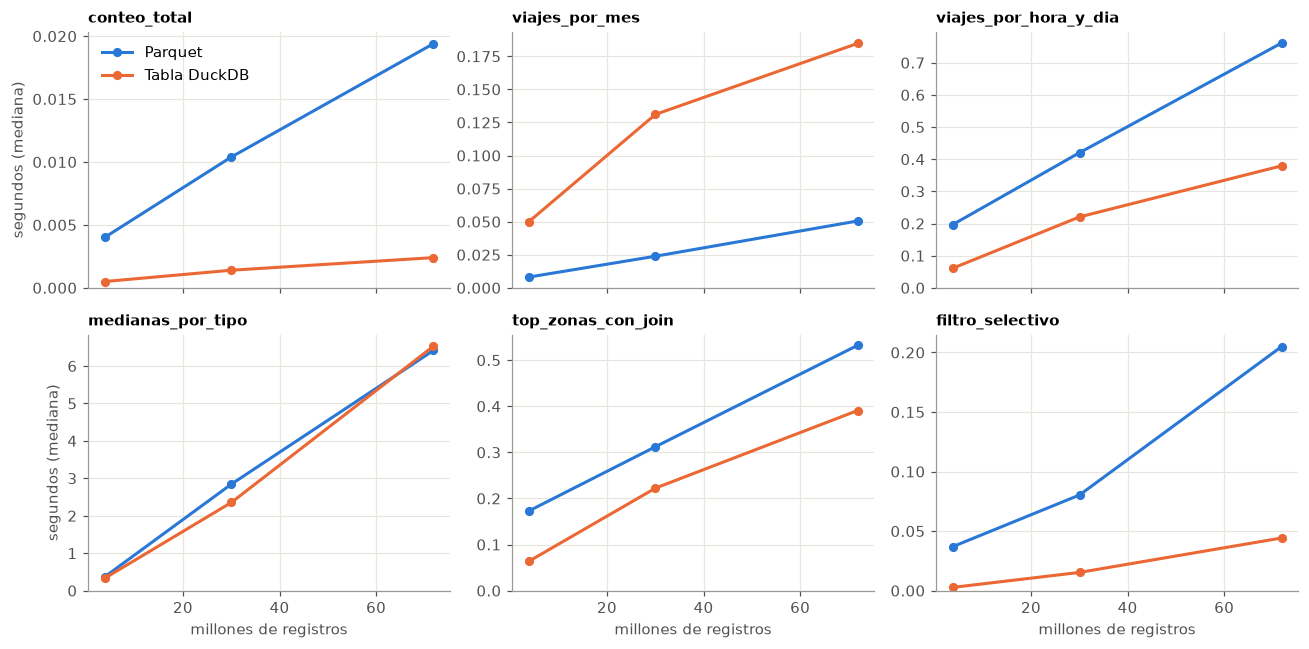

In [5]:
nombres = list(consultas)
fig, ejes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for eje, nombre in zip(ejes.flat, nombres):
    datos = tabla[tabla.consulta == nombre]
    eje.plot(datos.registros / 1e6, datos.parquet_s, color="#2a78d6", marker="o", markersize=5, label="Parquet")
    eje.plot(datos.registros / 1e6, datos.tabla_s, color="#eb6834", marker="o", markersize=5, label="Tabla DuckDB")
    eje.set_title(nombre, fontsize=10)
    eje.set_ylim(bottom=0)
ejes[0, 0].legend()
for eje in ejes[1]:
    eje.set_xlabel("millones de registros")
for eje in ejes[:, 0]:
    eje.set_ylabel("segundos (mediana)")
plt.tight_layout()

## 6.9 Análisis

**La tabla gana en casi todas las consultas, pero por poco en tiempo absoluto.** Con 71.9 millones de registros, el filtro selectivo baja de 0.205 a 0.044 segundos (4.7 veces), el conteo de 0.019 a 0.002 y la agregación por día y hora de 0.761 a 0.379. Todas siguen por debajo de un segundo con Parquet.

**Las consultas pesadas empatan.** Las medianas y percentiles tardan 6.4 segundos con Parquet y 6.5 con la tabla. El costo está en ordenar valores, no en leerlos, así que el formato de almacenamiento casi no influye.

**Agrupar por archivo es más rápido en Parquet.** `viajes_por_mes` tarda 0.050 segundos sobre Parquet y 0.185 sobre la tabla. El mes sale del nombre del archivo, así que en Parquet DuckDB casi no lee columnas de datos para resolverla. En la tabla esa información es una columna más que hay que recorrer.

**La ventaja de la tabla crece con el volumen, pero no linealmente.** Con un mes el filtro selectivo es 12 veces más rápido en la tabla (0.037 contra 0.003), con todo el conjunto es 4.7 veces. Con poco volumen el costo fijo de abrir los archivos Parquet pesa más que la lectura.

**Materializar cuesta.** Crear la tabla de todos los años tomó 13.5 segundos en el benchmark y 17.2 en `taxis.duckdb`, y el archivo ocupa 2.4 GB contra 1.2 GB de los Parquet originales. Ese costo se repite cada vez que llega un archivo nuevo.

## 6.10 Cuándo usar cada estrategia

**Consultar Parquet directo conviene** cuando los datos cambian seguido, se exploran una vez o pocas veces, el volumen no cabe dos veces en disco o la consulta agrupa por archivo o por partición. Es la opción de este laboratorio para todo el análisis, porque agregar un año no requiere recargar nada.

**Materializar conviene** cuando muchas consultas repetidas leen los mismos datos, sobre todo filtros selectivos y tableros que se refrescan seguido, o cuando una herramienta externa necesita un archivo de base de datos. Por eso Metabase lee `taxis.duckdb` y no los Parquet.